<img src="https://github.com/mariabda2/intro_data_2026/blob/main/sesiones_practicas/imgs/banner_fcd.jpg?raw=1" alt="bannersp" width="1100"  height="150">

# <span style="color:#2F749F;"><strong>📦 Sesión práctica 3: Codificación y transformación de variables</strong></span>
---
<p align="right">
  <a href="https://colab.research.google.com/github/mariabda2/intro_data_2026/blob/main/sesiones_practicas/sp_3_maria_bernarda_salazar.ipynb?clone=true" target="_blank">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Abrir en Colab"/>
  </a>
</p>

## <span style="color:black;"><strong>Datos del estudiante</strong></span>

Relacione sus datos y los del compañero de trabajo

## <span style="color:#2F749F;"><strong>Ejercicio 1: Comparación de métodos de escalamiento</strong></span>

A partir de un conjunto de datos real sobre **vinos**, analiza cómo cambia la escala de las variables al aplicar diferentes métodos de **escalamiento de datos**, y compara visualmente sus efectos sobre la distribución.

1. Carga el conjunto de datos **wine** desde la librería `sklearn.datasets` usando `load_wine()`.

2. Convierte el conjunto de datos en un **DataFrame de pandas** e identifica las variables disponibles.

3. Selecciona al menos **tres variables numéricas** para el análisis (por ejemplo):
   - `alcohol`
   - `malic_acid`
   - `color_intensity`

4. Aplica los siguientes métodos de escalamiento sobre las variables seleccionadas:
   - `StandardScaler`
   - `MinMaxScaler`
   - `RobustScaler`
   - `Z-Score`

5. Genera **gráficas comparativas** que permitan visualizar la distribución de al menos **una de las variables seleccionadas** en los siguientes escenarios:
   - Distribución **original**
   - Distribución con **StandardScaler**
   - Distribución con **MinMaxScaler**
   - Distribución con **RobustScaler**
   - Distribución con **Z-Score**

6. Escribe un análisis de **máximo cinco líneas** en el que expliques las diferencias entre las técnicas o métodos, su impacto en los resultados y cuál consideras más recomendable, justificando brevemente tu elección.

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
import numpy as np

wine = load_wine()
df = pd.DataFrame(wine.data, columns=wine.feature_names)

df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [26]:
variables = ['alcohol', 'malic_acid', 'color_intensity']
df_sel = df[variables]
df_sel.head()

,alcohol,malic_acid,color_intensity
0,14.23,1.71,5.64
1,13.20,1.78,4.38
2,13.16,2.36,5.68
3,14.37,1.95,7.80
4,13.24,2.59,4.32


In [27]:
scalers = {
    "StandardScaler": StandardScaler(),
    "MinMaxScaler": MinMaxScaler(),
    "RobustScaler": RobustScaler(),
    "Z-Score": StandardScaler()
}

scaled_data = {}

for name, scaler in scalers.items():
    scaled_data[name] = scaler.fit_transform(df_sel)

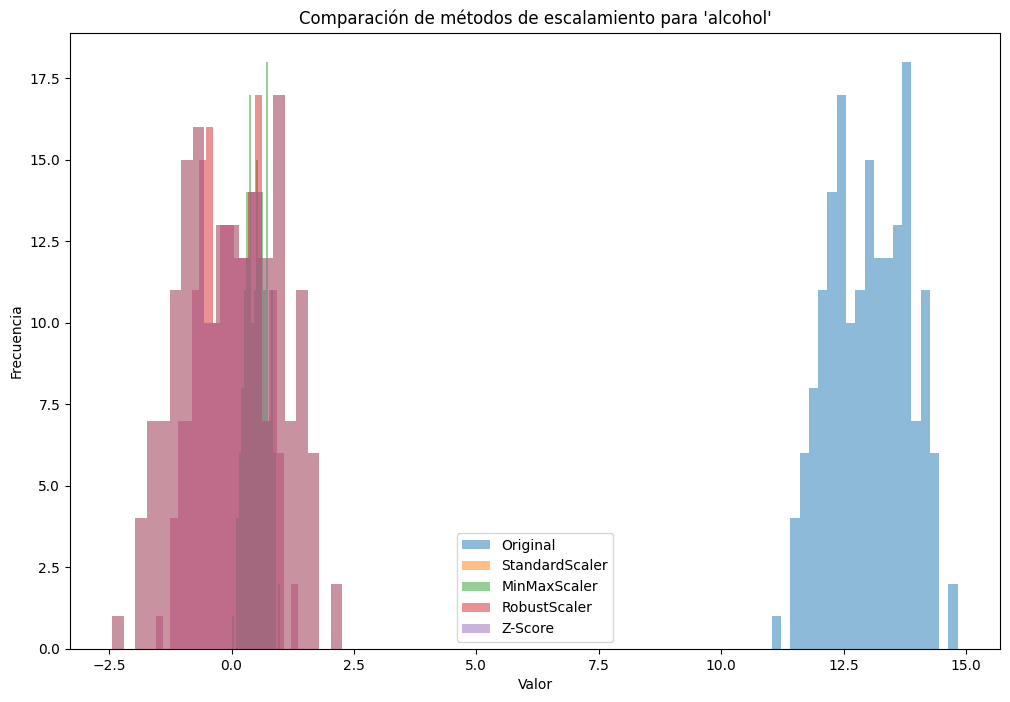

In [28]:
variable = 'alcohol'
idx = variables.index(variable)

plt.figure(figsize=(12, 8))

plt.hist(df_sel[variable], bins=20, alpha=0.5, label="Original")

for name, data in scaled_data.items():
    plt.hist(data[:, idx], bins=20, alpha=0.5, label=name)

plt.title(f"Comparación de métodos de escalamiento para '{variable}'")
plt.xlabel("Valor")
plt.ylabel("Frecuencia")
plt.legend()
plt.show()

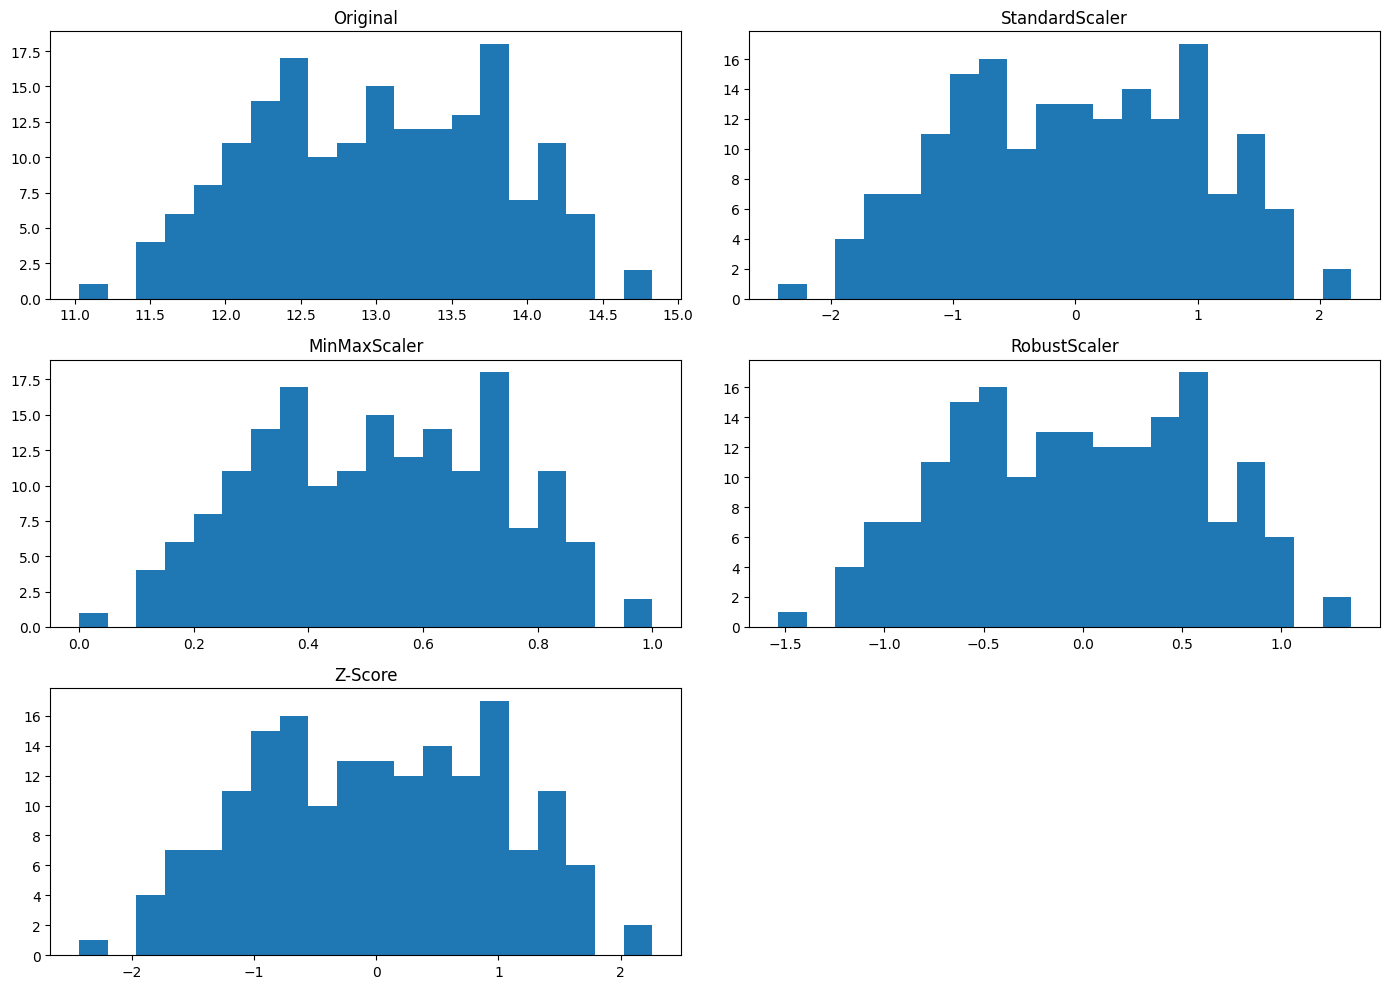

In [29]:
plt.figure(figsize=(14, 10))

plt.subplot(3, 2, 1)
plt.hist(df_sel[variable], bins=20)
plt.title("Original")

plt.subplot(3, 2, 2)
plt.hist(scaled_data["StandardScaler"][:, idx], bins=20)
plt.title("StandardScaler")

plt.subplot(3, 2, 3)
plt.hist(scaled_data["MinMaxScaler"][:, idx], bins=20)
plt.title("MinMaxScaler")

plt.subplot(3, 2, 4)
plt.hist(scaled_data["RobustScaler"][:, idx], bins=20)
plt.title("RobustScaler")

plt.subplot(3, 2, 5)
plt.hist(scaled_data["Z-Score"][:, idx], bins=20)
plt.title("Z-Score")

plt.tight_layout()
plt.show()

StandardScaler y Z-Score centran los datos en cero, esto funciona bien cuando
los datos siguen una distribución normal. MinMaxScaler pone todo entre 0 y 1,
esto sirve para modelos como redes neuronales. RobustScaler es el que mejor maneja los valores atípicos porque no se deja afectar tanto por ellos. Si comparamos, MinMax es el que más se distorsiona cuando hay outliers, mientras que RobustScaler se mantiene más estable.


## <span style="color:#2F749F;"><strong>Ejercicio 2: Comparación de escalamiento RobustScaler vs Z-Score</strong></span>

A partir de un conjunto de datos real sobre **diabetes**, analiza cómo cambia la escala de las variables al aplicar **estandarización con Z-Score** y **escalamiento robusto**, y compara visualmente sus efectos cuando existen **posibles valores atípicos**.

1. Carga el conjunto de datos **diabetes** desde la librería `sklearn.datasets` usando `load_diabetes()`.

2. Convierte el conjunto de datos en un **DataFrame de pandas** e identifica las variables disponibles.

3. Selecciona al menos **tres variables numéricas** para el análisis (por ejemplo: `bmi`, `bp`, `s5` u otras disponibles en el dataset).

4. Aplica los siguientes métodos de escalamiento sobre las variables seleccionadas:
   - **StandardScaler** (Z-Score).
   - **RobustScaler** (basado en mediana e IQR).

5. Genera **gráficas comparativas** que permitan visualizar la distribución de al menos **una de las variables seleccionadas** en los siguientes escenarios:
   - Distribución **original**
   - Distribución **escalada con Z-Score**
   - Distribución **escalada con RobustScaler**

6. Escribe un análisis de **máximo cinco líneas** en el que expliques las diferencias entre las técnicas o métodos, su impacto en los resultados y cuál consideras más recomendable, justificando brevemente tu elección.

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.preprocessing import StandardScaler, RobustScaler

# Cargar dataset
diabetes = load_diabetes()
df = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)

df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


In [31]:
variables = ['bmi', 'bp', 's5']
df_sel = df[variables]
df_sel.head()

,bmi,bp,s5
0,0.061696,0.021872,0.019907
1,-0.051474,-0.026328,-0.068332
2,0.044451,-0.005670,0.002861
3,-0.011595,-0.036656,0.022688
4,-0.036385,0.021872,-0.031988


In [32]:
scalers = {
    "Z-Score": StandardScaler(),
    "RobustScaler": RobustScaler()
}

scaled_data = {}

for name, scaler in scalers.items():
    scaled_data[name] = scaler.fit_transform(df_sel)

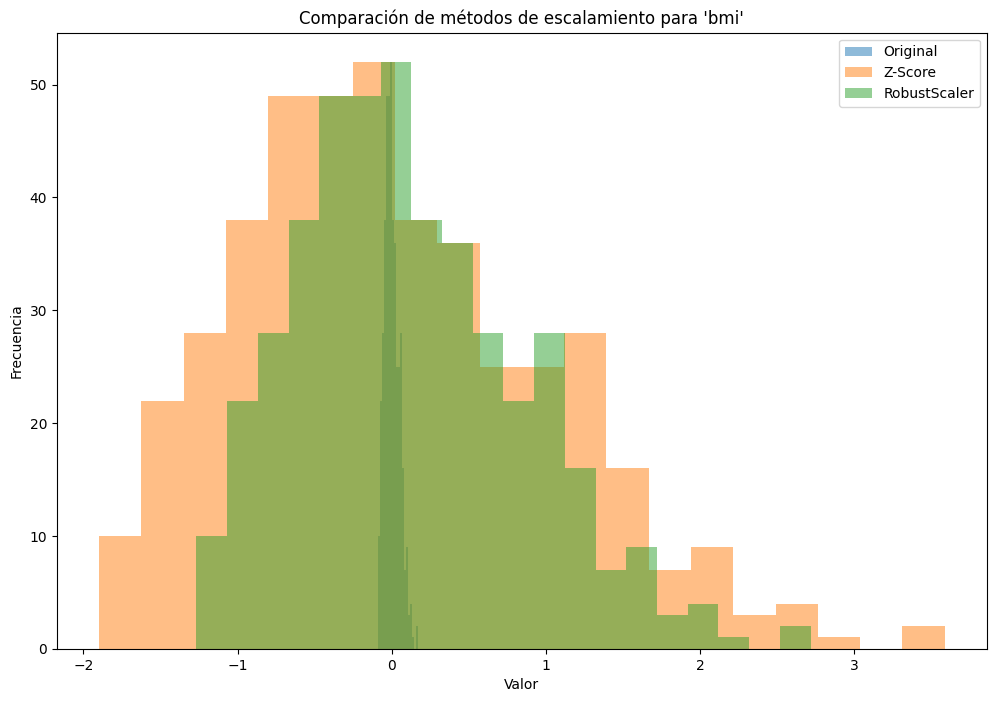

In [33]:
variable = 'bmi'
idx = variables.index(variable)

plt.figure(figsize=(12, 8))

plt.hist(df_sel[variable], bins=20, alpha=0.5, label="Original")

for name, data in scaled_data.items():
    plt.hist(data[:, idx], bins=20, alpha=0.5, label=name)

plt.title(f"Comparación de métodos de escalamiento para '{variable}'")
plt.xlabel("Valor")
plt.ylabel("Frecuencia")
plt.legend()
plt.show()

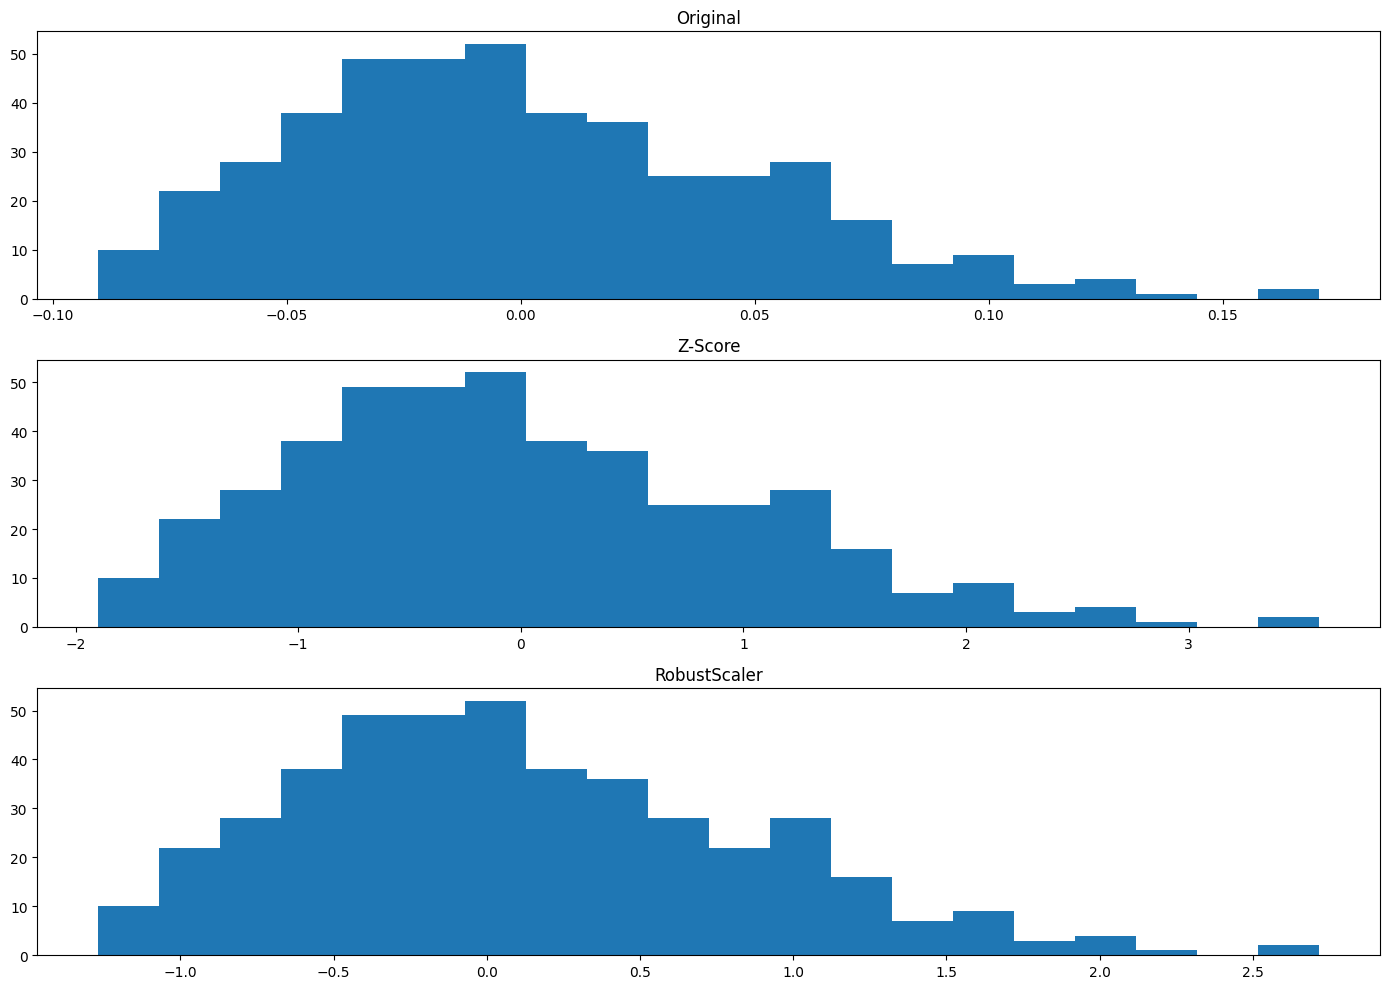

In [34]:
plt.figure(figsize=(14, 10))

plt.subplot(3, 1, 1)
plt.hist(df_sel[variable], bins=20)
plt.title("Original")

plt.subplot(3, 1, 2)
plt.hist(scaled_data["Z-Score"][:, idx], bins=20)
plt.title("Z-Score")

plt.subplot(3, 1, 3)
plt.hist(scaled_data["RobustScaler"][:, idx], bins=20)
plt.title("RobustScaler")

plt.tight_layout()
plt.show()

Z-Score centra los datos en cero y los escala usando la desviación estándar, pero si hay valores atípicos, se altera la distribución porque la media y la desviación se ven afectadas. RobustScaler usa la mediana
y el rango intercuartílico, que no se mueven tanto con los outliers, así
que la forma de la distribución se mantiene más fija. En las gráficas se nota
que Z-Score estira más los datos, mientras que RobustScaler los deja más
compactos. Seria mejor usar RobustScaler.


## <span style="color:#2F749F;"><strong>Ejercicio 3: Comparación de normalización L1 y L2</strong></span>

A partir de un conjunto de datos real sobre **precios de viviendas**, analiza cómo cambian los valores de las variables al aplicar **normalización L1 y L2**, y compara visualmente sus efectos sobre la distribución de los datos.

1. Carga el conjunto de datos **California Housing** desde la librería `sklearn.datasets` usando `fetch_california_housing()`.

2. Convierte el conjunto de datos en un **DataFrame de pandas** e identifica las variables disponibles.

3. Selecciona al menos **tres variables numéricas** para el análisis (por ejemplo):
   - `MedInc`
   - `AveRooms`
   - `HouseAge`

4. Aplica los siguientes métodos de **normalización** sobre las variables seleccionadas utilizando `Normalizer` de `sklearn.preprocessing`:
   - **Normalización L1**
   - **Normalización L2**

5. Genera **gráficas comparativas** que permitan visualizar la distribución de al menos **una de las variables seleccionadas** en los siguientes escenarios:
   - Distribución **original**
   - Distribución con **normalización L1**
   - Distribución con **normalización L2**

6. Escribe un análisis de **máximo cinco líneas** en el que expliques las diferencias entre las técnicas o métodos, su impacto en los resultados y cuál consideras más recomendable, justificando brevemente tu elección.

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import Normalizer

housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [36]:
variables = ['MedInc', 'AveRooms', 'HouseAge']
df_sel = df[variables]
df_sel.head()

,MedInc,AveRooms,HouseAge
0,8.3252,6.984127,41.0
1,8.3014,6.238137,21.0
2,7.2574,8.288136,52.0
3,5.6431,5.817352,52.0
4,3.8462,6.281853,52.0


In [37]:
normalizers = {
    "L1": Normalizer(norm='l1'),
    "L2": Normalizer(norm='l2')
}

normalized_data = {}

for name, normalizer in normalizers.items():
    normalized_data[name] = normalizer.fit_transform(df_sel)

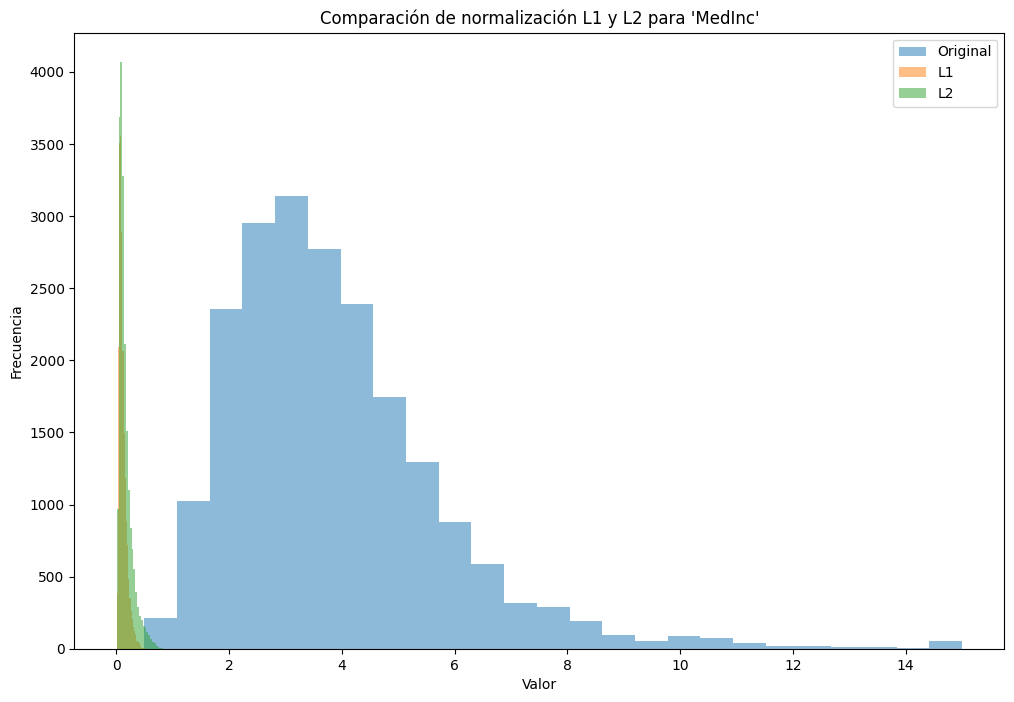

In [38]:
variable = 'MedInc'
idx = variables.index(variable)

plt.figure(figsize=(12, 8))

plt.hist(df_sel[variable], bins=25, alpha=0.5, label="Original")

for name, data in normalized_data.items():
    plt.hist(data[:, idx], bins=25, alpha=0.5, label=name)

plt.title(f"Comparación de normalización L1 y L2 para '{variable}'")
plt.xlabel("Valor")
plt.ylabel("Frecuencia")
plt.legend()
plt.show()

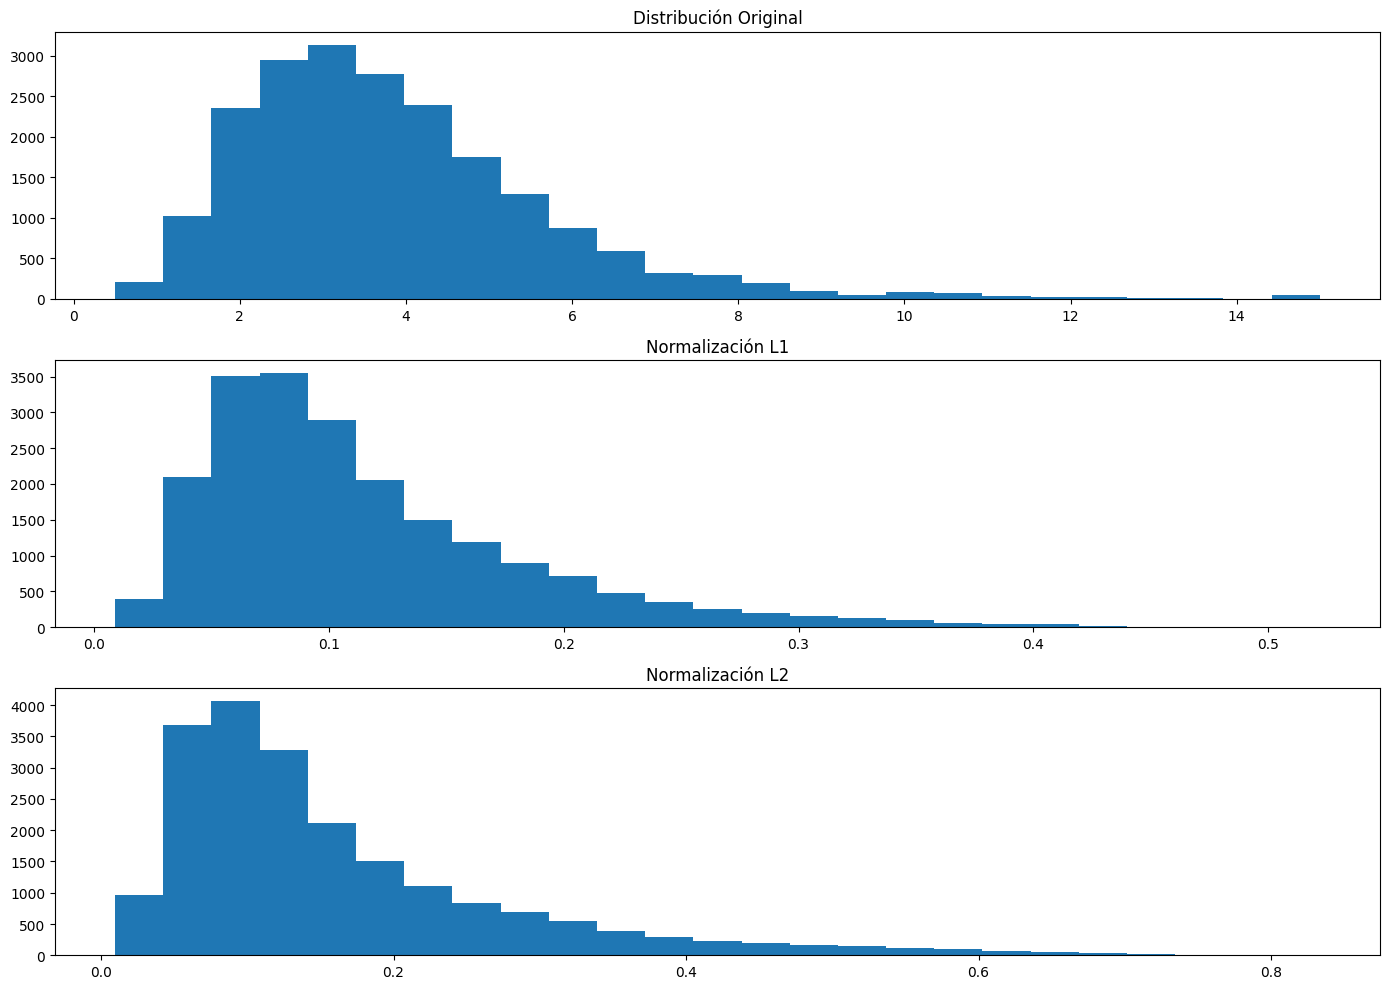

In [39]:
plt.figure(figsize=(14, 10))

plt.subplot(3, 1, 1)
plt.hist(df_sel[variable], bins=25)
plt.title("Distribución Original")

plt.subplot(3, 1, 2)
plt.hist(normalized_data["L1"][:, idx], bins=25)
plt.title("Normalización L1")

plt.subplot(3, 1, 3)
plt.hist(normalized_data["L2"][:, idx], bins=25)
plt.title("Normalización L2")

plt.tight_layout()
plt.show()

L1 normaliza cada fila haciendo que la suma de los valores absolutos sea 1. Esto
hace que los valores pequeños suban un poco y los grandes bajen mucho. L2, en cambio, ajusta los datos para que la distancia al origen de cada fila sea 1, lo que conserva mejor las relaciones entre las variables.


## <span style="color:#2F749F;"><strong>Ejercicio 4: Comparación de transformaciones para reducir asimetría</strong></span>

A partir de un conjunto de datos real sobre **pacientes con diabetes**, analiza cómo cambian las distribuciones de algunas variables clínicas al aplicar diferentes **transformaciones matemáticas utilizadas para reducir la asimetría (skewness) o estabilizar la varianza**.

1. Carga el conjunto de datos **diabetes** desde la librería `sklearn.datasets` usando `load_diabetes()`.

2. Convierte el conjunto de datos en un **DataFrame de pandas** e identifica las variables disponibles.

3. Selecciona al menos **dos variables numéricas** para el análisis (por ejemplo: `bmi`, `bp` o `s5`).

4. Aplica las siguientes **transformaciones** sobre una de las variables seleccionadas:

   - **Transformación logarítmica** usando `np.log()` o `np.log1p()`
   - **Transformación logarítmica reflejada** (útil cuando existe asimetría negativa)
   - **Transformación cuadrática** usando `x²`
   - **Transformación Box-Cox** usando `scipy.stats.boxcox`

5. Genera **gráficas comparativas** que permitan visualizar la distribución de la variable en los siguientes escenarios:
   - Distribución **original**
   - Distribución con **transformación log**
   - Distribución con **log reflejado**
   - Distribución con **transformación cuadrática**
   - Distribución con **transformación Box-Cox**

6. Escribe un análisis de **máximo cinco líneas** en el que expliques las diferencias entre las técnicas o métodos, su impacto en los resultados y cuál consideras más recomendable, justificando brevemente tu elección.

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from scipy.stats import boxcox

diabetes = load_diabetes()
df = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)

df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


In [41]:
variables = ['bmi', 's5']
df_sel = df[variables]
df_sel.head()

,bmi,s5
0,0.061696,0.019907
1,-0.051474,-0.068332
2,0.044451,0.002861
3,-0.011595,0.022688
4,-0.036385,-0.031988


In [42]:
variable = 'bmi'
x = df_sel[variable]

In [43]:
log_x = np.log1p(x - x.min() + 1)
reflected_log_x = np.log1p(x.max() - x + 1)
quad_x = x**2


In [44]:
from scipy.stats import boxcox

bmi_positive = df["bmi"] - df["bmi"].min() + 1
df["bmi_boxcox"], fitted_lambda = boxcox(bmi_positive)
fitted_lambda

np.float64(-4.560011830905982)

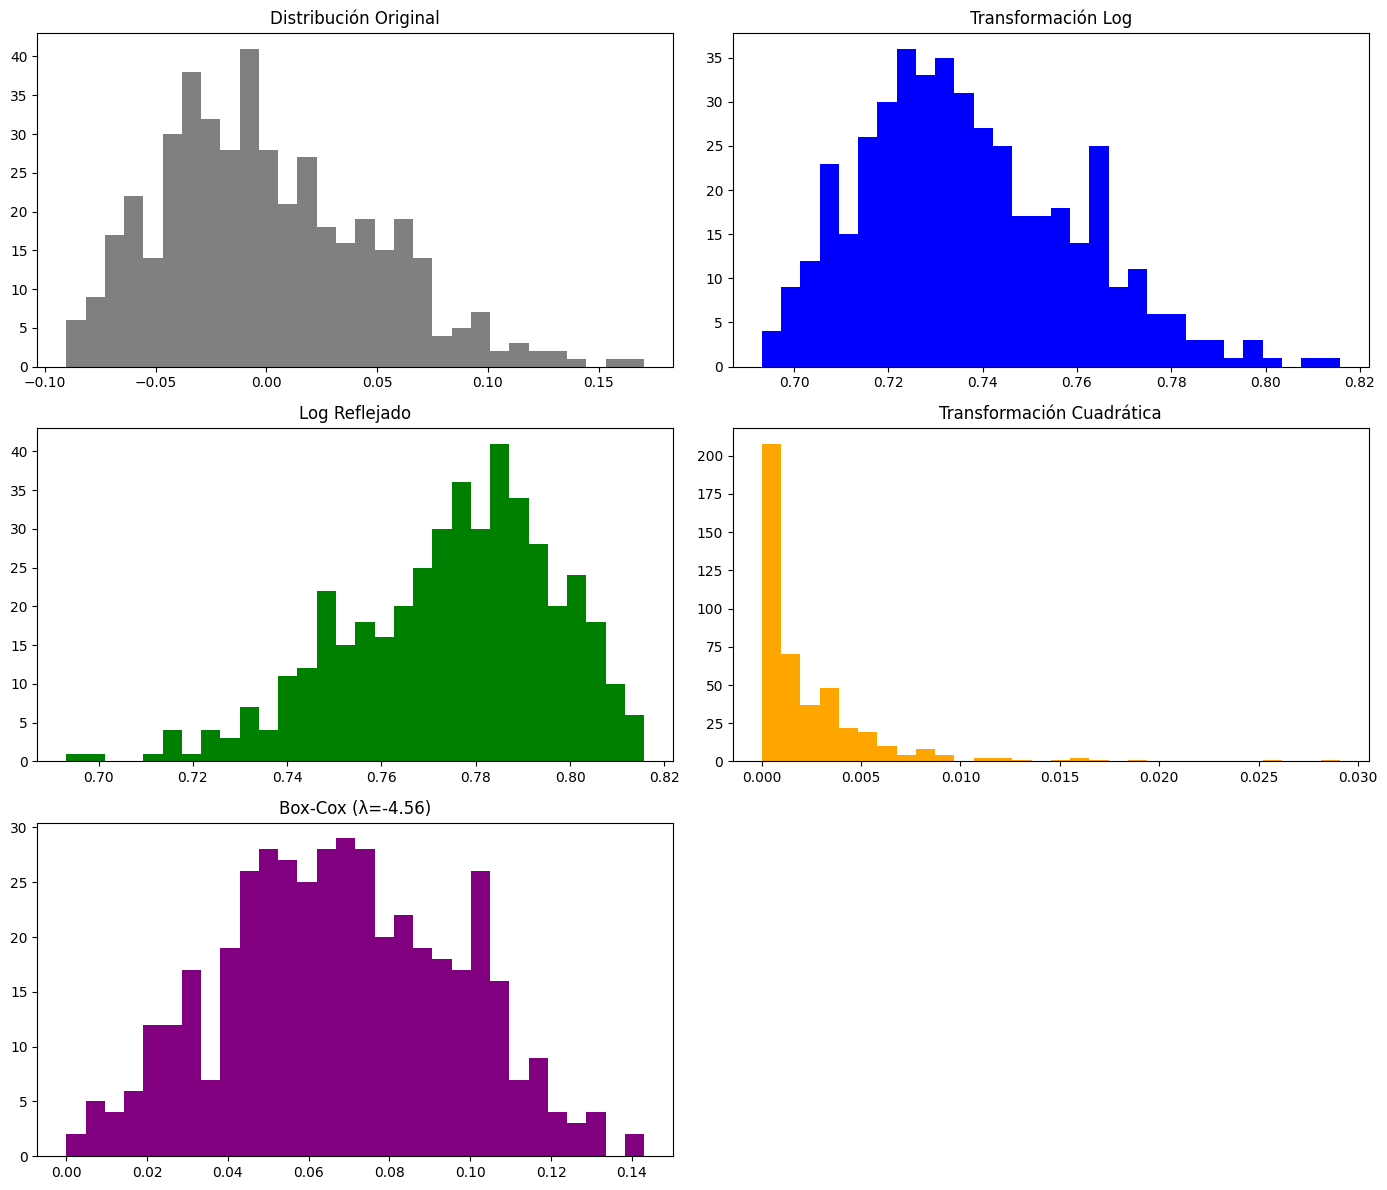

In [45]:
plt.figure(figsize=(14, 12))

plt.subplot(3, 2, 1)
plt.hist(x, bins=30, color='gray')
plt.title("Distribución Original")

plt.subplot(3, 2, 2)
plt.hist(log_x, bins=30, color='blue')
plt.title("Transformación Log")

plt.subplot(3, 2, 3)
plt.hist(reflected_log_x, bins=30, color='green')
plt.title("Log Reflejado")

plt.subplot(3, 2, 4)
plt.hist(quad_x, bins=30, color='orange')
plt.title("Transformación Cuadrática")

plt.subplot(3, 2, 5)
plt.hist(boxcox_x, bins=30, color='purple')
plt.title(f"Box-Cox (λ={lambda_bc:.2f})")

plt.tight_layout()
plt.show()

La transformación logarítmica es buena para datos con cola larga hacia la derecha porque aplasta los valores grandes y ayuda a que se vean
más normales. Si la cola es hacia la izquierda, mejor usar el
log reflejado. La cuadrática empeora la asimetría y la varianza. Box-Cox es el mejor porque ajusta un parámetro λ para adaptarse a los datos y da una distribución más cercana a la normal. Por eso, Box-cox sirve mas para reducir asimetria.

## <span style="color:#2F749F;"><strong>Ejercicio 5: Comparación de transformaciones para reducir asimetría</strong></span>

A partir de un conjunto de datos real sobre **pacientes con enfermedades cardíacas**, analiza cómo cambian las distribuciones de algunas variables clínicas al aplicar diferentes **transformaciones matemáticas utilizadas para reducir la asimetría (skewness) o estabilizar la varianza**.

1. Carga el conjunto de datos **Heart Disease** desde la librería `ucimlrepo` usando `load_dataset("heart_disease = fetch_ucirepo(id=45)")`.

2. Convierte el conjunto de datos en un **DataFrame de pandas** e identifica las variables disponibles.

3. Selecciona al menos **dos variables numéricas** para el análisis (por ejemplo:  
   - `chol` (colesterol)  
   - `trestbps` (presión arterial en reposo)  
   - `thalach` (frecuencia cardíaca máxima)).

4. Aplica las siguientes **transformaciones** sobre una de las variables seleccionadas:

   - **Raíz cuadrada** usando `np.sqrt()`  
   - **Recíproca** usando `1/x`  
   - **Transformación Yeo-Johnson** usando `PowerTransformer(method="yeo-johnson")`

5. Genera **gráficas comparativas** que permitan visualizar la distribución de la variable en los siguientes escenarios:
   - Distribución **original**
   - Distribución con **transformación raíz cuadrada**
   - Distribución con **transformación recíproca**
   - Distribución con **transformación Yeo-Johnson**

6. Escribe un análisis de **máximo cinco líneas** en el que expliques las diferencias entre las técnicas o métodos, su impacto en los resultados y cuál consideras más recomendable, justificando brevemente tu elección.

In [46]:
!pip install ucimlrepo

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from ucimlrepo import fetch_ucirepo
from sklearn.preprocessing import PowerTransformer

heart = fetch_ucirepo(id=45)

df = heart.data.features
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0


In [48]:
variables = ['chol', 'trestbps', 'thalach']
df_sel = df[variables]
df_sel.head()

,chol,trestbps,thalach
0,233,145,150
1,286,160,108
2,229,120,129
3,250,130,187
4,204,130,172


In [49]:
variable = 'chol'
x = df_sel[variable]

In [50]:
sqrt_x = np.sqrt(x)
reciprocal_x = 1 / (x + 1e-6)
pt = PowerTransformer(method='yeo-johnson')
yeojohnson_x = pt.fit_transform(x.values.reshape(-1, 1)).flatten()

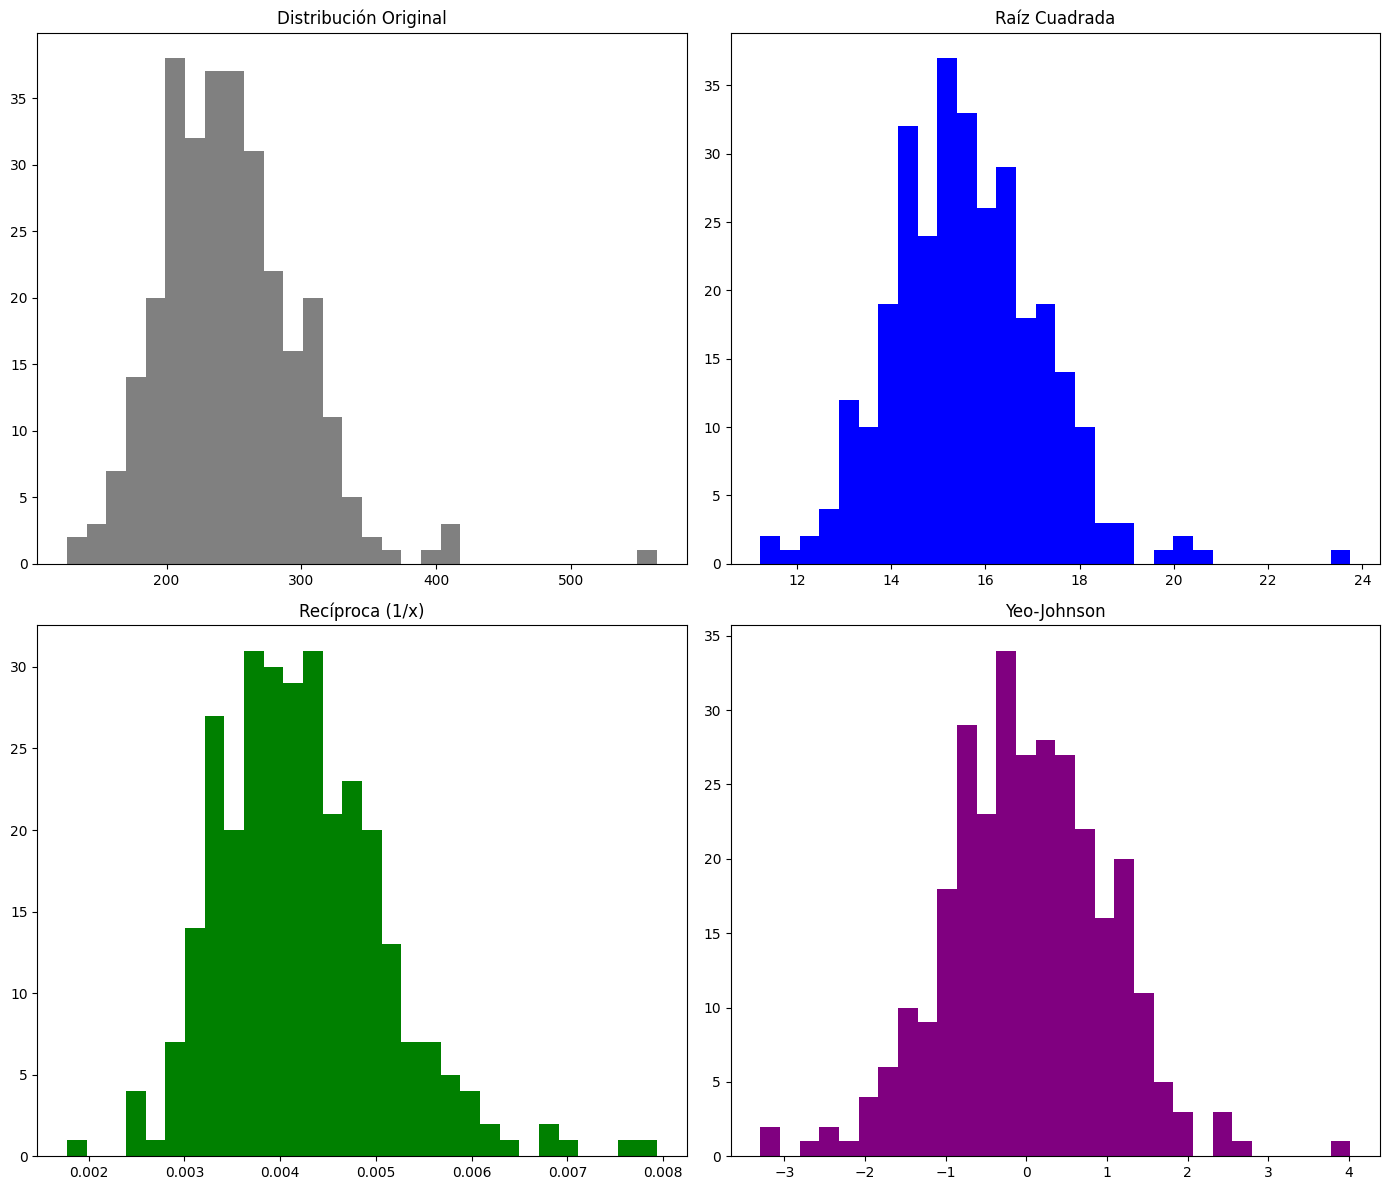

In [51]:
plt.figure(figsize=(14, 12))

plt.subplot(2, 2, 1)
plt.hist(x, bins=30, color='gray')
plt.title("Distribución Original")

plt.subplot(2, 2, 2)
plt.hist(sqrt_x, bins=30, color='blue')
plt.title("Raíz Cuadrada")

plt.subplot(2, 2, 3)
plt.hist(reciprocal_x, bins=30, color='green')
plt.title("Recíproca (1/x)")

plt.subplot(2, 2, 4)
plt.hist(yeojohnson_x, bins=30, color='purple')
plt.title("Yeo-Johnson")

plt.tight_layout()
plt.show()

La raíz cuadrada ayuda con la asimetría, aplasta los valores
grandes, pero si los datos están muy sesgados, no es suficiente. La recíproca
(1/x) da vuelta la escala, lo que genera valores extremos si hay números
muy pequeños, así que no es muy estable. Yeo-Johnson
es la mejor: funciona con positivos, negativos y hasta ceros, y ajusta
la transformación para que los datos queden lo más normales posible. Por eso,
Yeo-Johnson es la mejor opción.
